# Análisis de Categorias en Retail — Ventas de productos
**Autor:** Rodolfo Gabriel Riveros Lobos | **Fecha:** 23/04/2026  
**Objetivo:** Identificar cuales son los productos que generan mejores ingresos, donde están las oportunidades de mejora.

📦 # Dataset
Superstore Sales Dataset (Kaggle) — el dataset más usado en entrevistas de Analytics a nivel mundial.
🔗 https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
Ventas reales simuladas de una cadena retail USA con categorías, regiones, descuentos, profit y más.

#Sumario Ejecutivo

# Executive Summary

- Technology lidera ventas y crecimiento (+5.97%)
- Furniture presenta caída (-15.24% en el último período) y bajo margen (2.49%)
- Región Central tiene margen inferior (7.92% vs 11.93% del Sur)
- Clientes "Campeones" representan 7.76% del revenue

**Acciones clave:**
1. Escalar Technology
2. Revisar Furniture
3. Auditar Región Central
4. Activar clientes en riesgo

In [19]:
# Instalar la librería de Kaggle
!pip install kaggle

### Configuración de la API de Kaggle

Para descargar el dataset de Kaggle, es recomendable configurar credenciales. Se sugiere loguearse en la plataforma y desde panel de cuenta decargar archivo `kaggle.json` en `/content/`.

Luego ejecutar el siguiente código para crear el directorio `~/.kaggle/` y mover el archivo `kaggle.json` allí. Esto permitirá que la librería de Kaggle autentique  solicitudes.


In [20]:
# Crear directorio .kaggle
!mkdir -p ~/.kaggle
# Moviendo el archivo kaggle.json al directorio de configuración de Kaggle
!mv /content/kaggle.json ~/.kaggle/
# Estableciendo permisos adecuados para el archivo (solo lectura para el propietario)
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key configurada correctamente.")

mv: cannot stat '/content/kaggle.json': No such file or directory
Kaggle API key configurada correctamente.


### Descargar el Dataset

Ahora podemos descargar el dataset 'superstore-dataset-final' de Kaggle.

In [21]:
# Descarga del dataset
# URL del dataset es: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
# El identificador del dataset es: vivek468/superstore-dataset-final
!kaggle datasets download -d vivek468/superstore-dataset-final

Dataset URL: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
License(s): other
superstore-dataset-final.zip: Skipping, found more recently modified local copy (use --force to force download)


### Descomprimir el Dataset

El dataset se descargará como un archivo `.zip`. Debemos descomprimirlo para acceder al archivo `Sample - Superstore.csv`.

In [22]:
# Descomprimir el archivo zip descargado
!unzip superstore-dataset-final.zip

print("Dataset descomprimido. Ahora deberías encontrar 'Sample - Superstore.csv' en el directorio actual.")

Archive:  superstore-dataset-final.zip
replace Sample - Superstore.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: Sample - Superstore.csv  
Dataset descomprimido. Ahora deberías encontrar 'Sample - Superstore.csv' en el directorio actual.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print(df.shape)
print(df.columns.tolist())
df.head()

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [24]:
# Convertir las columnas de fecha al tipo datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Obtener el período cubierto
min_order_date = df['Order Date'].min()
max_order_date = df['Order Date'].max()

# Contar el número de órdenes únicas
num_orders = df['Order ID'].nunique()

# Obtener los nombres de las columnas
column_names = df.columns.tolist()

print(f"Columnas: {column_names}")
print(f"Período cubierto: Desde {min_order_date.strftime('%d/%m/%Y')} hasta {max_order_date.strftime('%d/%m/%Y')}")
print(f"Número de órdenes únicas: {num_orders}")

Columnas: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Período cubierto: Desde 03/01/2014 hasta 30/12/2017
Número de órdenes únicas: 5009


### Resumen del Dataset

- **Columnas:** El dataset contiene las siguientes 21 columnas: `Row ID`, `Order ID`, `Order Date`, `Ship Date`, `Ship Mode`, `Customer ID`, `Customer Name`, `Segment`, `Country`, `City`, `State`, `Postal Code`, `Region`, `Product ID`, `Category`, `Sub-Category`, `Product Name`, `Sales`, `Quantity`, `Discount`, `Profit`.
- **Período cubierto:** El rango de fechas de las órdenes va desde **03/01/2014** hasta **30/12/2017**.
- **Número de órdenes:** Hay un total de **5009** órdenes únicas en este dataset.

#Tipos de datos y verificación de nulos y/o duplicados

In [25]:
# Verificar nulos y duplicados
print(df.isnull().sum())
print(f"Duplicados: {df.duplicated().sum()}")
print(df.dtypes)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicados: 0
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float6

#Análisis de ventas por categoría

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


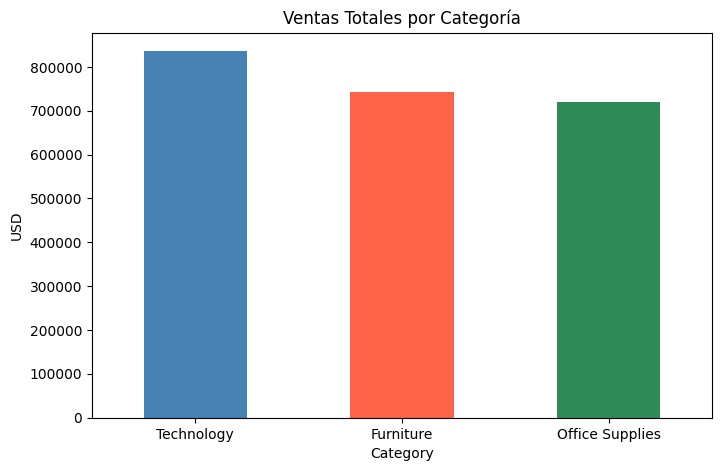

In [26]:
ventas_cat = df.groupby('Category')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)
print(ventas_cat)

ventas_cat['Sales'].plot(kind='bar', color=['steelblue','tomato','seagreen'], figsize=(8,5))
plt.title('Ventas Totales por Categoría')
plt.ylabel('USD')
plt.xticks(rotation=0)
plt.show()

#Análisis de rentabilidad: ¿qué categoría pierde plata?

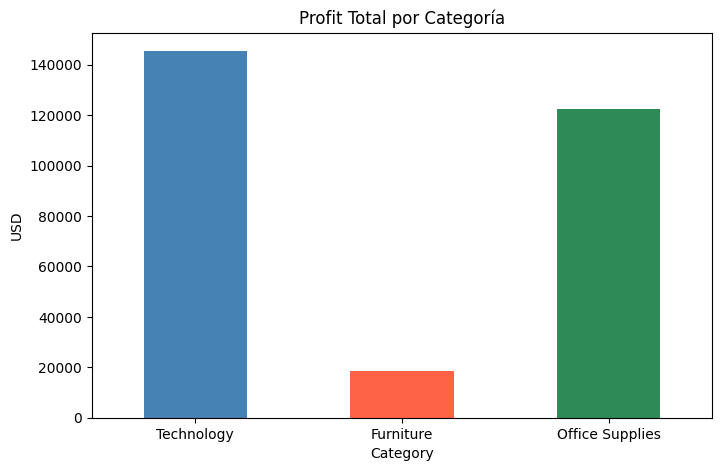

                       Sales       Profit  Margen_%
Category                                           
Technology       836154.0330  145454.9481     17.40
Furniture        741999.7953   18451.2728      2.49
Office Supplies  719047.0320  122490.8008     17.04


In [27]:
ventas_cat['Profit'].plot(kind='bar', color=['steelblue','tomato','seagreen'], figsize=(8,5))
plt.title('Profit Total por Categoría')
plt.ylabel('USD')
plt.xticks(rotation=0)
plt.show()

# Margen de ganancia
ventas_cat['Margen_%'] = (ventas_cat['Profit'] / ventas_cat['Sales'] * 100).round(2)
print(ventas_cat)

## Participación de ventas por categoría

In [28]:
sales_by_category = df.groupby('Category')['Sales'].sum()

sales_pct = (sales_by_category / sales_by_category.sum()) * 100

sales_pct = sales_pct.sort_values(ascending=False)

print("Participación de ventas por categoría (%):")
print(sales_pct)

Participación de ventas por categoría (%):
Category
Technology         36.398821
Furniture          32.300171
Office Supplies    31.301008
Name: Sales, dtype: float64


## Margen por categoría en porcentajes

In [29]:
profit_by_category = df.groupby('Category')['Profit'].sum()

margin_pct = (profit_by_category / sales_by_category) * 100

margin_pct = margin_pct.sort_values(ascending=False)

print("Margen por categoría (%):")
print(margin_pct)

Margen por categoría (%):
Category
Technology         17.395712
Office Supplies    17.035158
Furniture           2.486695
dtype: float64


#Tendencia de ventas mensual

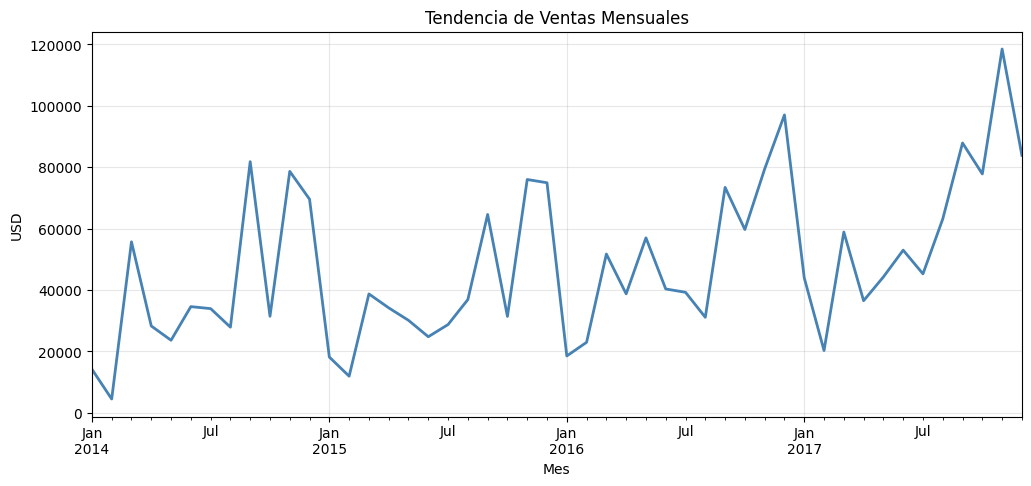

In [30]:
df['Mes'] = df['Order Date'].dt.to_period('M')
ventas_mes = df.groupby('Mes')['Sales'].sum()

ventas_mes.plot(figsize=(12,5), color='steelblue', linewidth=2)
plt.title('Tendencia de Ventas Mensuales')
plt.ylabel('USD')
plt.xlabel('Mes')
plt.grid(True, alpha=0.3)
plt.show()

### Comparación de Tendencia de Ventas Mensuales por Categoría

Ahora, para una comparación directa, visualicemos las tendencias de ventas de todas las categorías en un solo gráfico. Esto nos ayudará a identificar rápidamente qué categoría lidera en ventas en diferentes momentos y cómo interactúan sus patrones de crecimiento.

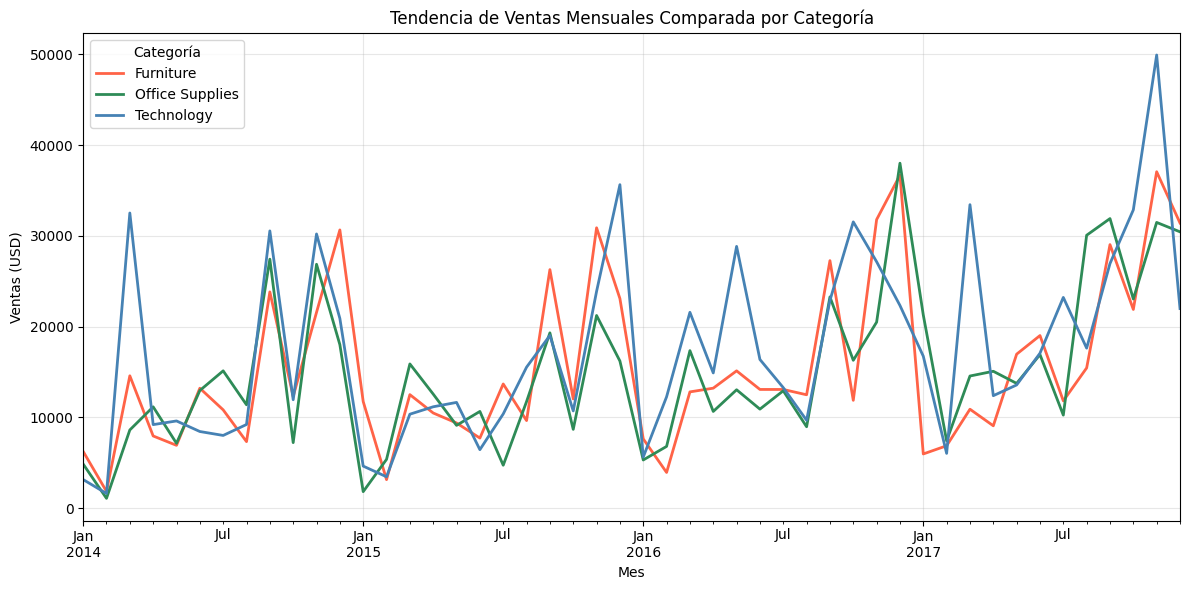

In [31]:
df['Mes'] = df['Order Date'].dt.to_period('M')

# Agrupar ventas por mes y por categoría
ventas_mensuales_categoria = df.groupby(['Mes', 'Category'])['Sales'].sum().unstack(fill_value=0)

# Definir colores para las categorías (asegurarse de que existan)
category_colors = {
    'Technology': 'steelblue',
    'Furniture': 'tomato',
    'Office Supplies': 'seagreen'
}

plt.figure(figsize=(12, 6))

# Usar el DataFrame ventas_mensuales_categoria que ya tiene los datos agrupados
# y los colores definidos previamente
for category in ventas_mensuales_categoria.columns:
    ventas_mensuales_categoria[category].plot(label=category, color=category_colors.get(category, 'gray'), linewidth=2)

plt.title('Tendencia de Ventas Mensuales Comparada por Categoría')
plt.xlabel('Mes')
plt.ylabel('Ventas (USD)')
plt.grid(True, alpha=0.3)
plt.legend(title='Categoría')
plt.tight_layout()
plt.show()

In [32]:
# Calculando el crecimiento promedio para los últimos 3 meses

# Verificar si growth es un DataFrame y tiene un índice que puede ser ordenado temporalmente
# (Assuming 'growth' has been calculated in the previous step and 'Mes' is the index name)
if isinstance(growth, pd.DataFrame) and 'Mes' in growth.index.names:
    # Seleccionar los últimos 3 meses de crecimiento
    growth_last_3_months = growth.iloc[-3:]

    # Calcular el crecimiento promedio por categoría
    avg_growth_last_3_months = growth_last_3_months.mean().round(2)

    print("Crecimiento promedio de los últimos 3 meses por categoría (%):")
    print(avg_growth_last_3_months)
else:
    print("El DataFrame 'growth' no está en el formato esperado para calcular el promedio de los últimos 3 meses.")
    print("Asegúrate de que 'growth' sea un DataFrame y que su índice incluya 'Mes'.")

Crecimiento promedio de los últimos 3 meses por categoría (%):
Category
Furniture          9.83
Office Supplies    1.85
Technology         5.97
dtype: float64


#### Insights de Tendencia de Ventas Mensuales por Categoría

**Implicación:**
- Priorizar inversión en Technology
- Revisar estrategia en Furniture

## Growth Rate (crecimiento mensual por categoría)

In [33]:
# Calcular growth %
growth = ventas_mensuales_categoria.pct_change() * 100

# Mostrar últimos períodos
growth.tail()

Category,Furniture,Office Supplies,Technology
Mes,,,
2017-08,30.719083,193.511165,-24.087815
2017-09,87.983699,6.107785,52.916484
2017-10,-24.611021,-27.773685,21.946877
2017-11,69.331930,36.615335,51.933543
2017-12,-15.244870,-3.289857,-55.958633


## Detectando categorías en caída

In [34]:
# Último growth disponible
latest_growth = growth.iloc[-1].sort_values()

# Categorías con caída
falling_categories = latest_growth[latest_growth < 0]

print("Categorías en caída (% último período):")
print(falling_categories)

Categorías en caída (% último período):
Category
Technology        -55.958633
Furniture         -15.244870
Office Supplies    -3.289857
Name: 2017-12, dtype: float64


## Top productos dentro de cada categoría

In [35]:
top_products = df.groupby(['Category', 'Product Name'])['Sales'] \
                 .sum() \
                 .reset_index() \
                 .sort_values(['Category', 'Sales'], ascending=[True, False])

# Top 5 por categoría
top_products.groupby('Category').head(5)

,Category,Product Name,Sales
206,Furniture,HON 5400 Series Task Chairs for Big and Tall,21870.5760
321,Furniture,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.9656
40,Furniture,Bretford Rectangular Conference Table Tops,12995.2915
201,Furniture,Global Troy Executive Leather Low-Back Tilter,12975.3820
325,Furniture,SAFCO Arco Folding Chair,11572.7800
775,Office Supplies,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.3840
804,Office Supplies,GBC DocuBind TL300 Electric Binding System,19823.4790
806,Office Supplies,GBC Ibimaster 500 Manual ProClick Binding System,19024.5000
801,Office Supplies,GBC DocuBind P400 Electric Binding System,17965.0680
857,Office Supplies,High Speed Automatic Electric Letter Opener,17030.3120


In [36]:
# Volatilidad (riesgo)
volatility = growth.std()

ventas_cat['Volatility %'] = volatility
print(ventas_cat)


                       Sales       Profit  Margen_%  Volatility %
Category                                                         
Technology       836154.0330  145454.9481     17.40    292.756216
Furniture        741999.7953   18451.2728      2.49    130.702994
Office Supplies  719047.0320  122490.8008     17.04    131.267794


Esta celda calcula la Volatility % (volatilidad porcentual) para cada categoría de producto, basándose en la desviación estándar del crecimiento mensual de sus ventas.

La volatilidad indica qué tan estables o variables son las ventas de una categoría mes a mes.

Categorías con alta volatilidad presentan mayor incertidumbre en ventas, lo que implica riesgo en planificación de stock y revenue.

### Relación entre Ventas y Ganancias por Producto

Analicemos la relación entre las ventas y las ganancias a nivel de producto para identificar aquellos que son menos rentables o que generan pérdidas, a pesar de tener un volumen de ventas considerable.

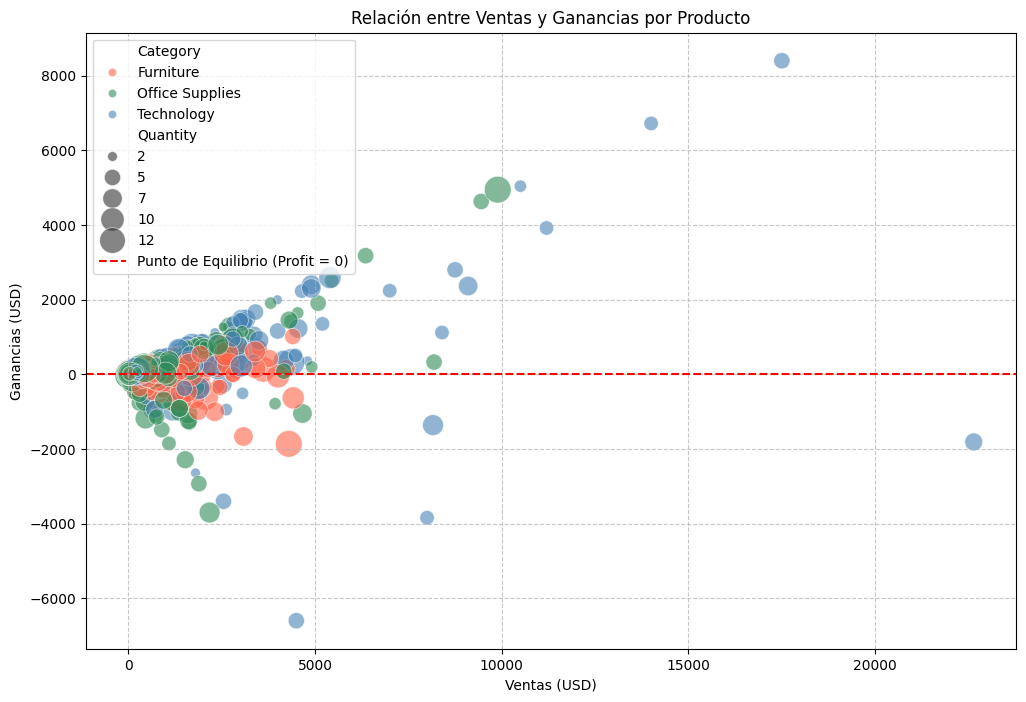

In [37]:
category_colors = {
    'Technology': 'steelblue',
    'Furniture': 'tomato',
    'Office Supplies': 'seagreen'
}

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', palette=category_colors, size='Quantity', sizes=(20, 400), alpha=0.6)
plt.title('Relación entre Ventas y Ganancias por Producto')
plt.xlabel('Ventas (USD)')
plt.ylabel('Ganancias (USD)')
plt.axhline(y=0, color='r', linestyle='--', label='Punto de Equilibrio (Profit = 0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Análisis profundo usando téncnicas de Pareto y RFM

### Análisis ABC (Pareto) por Ventas de Productos

El análisis ABC nos permitirá clasificar los productos según su contribución a las ventas totales, aplicando el principio de Pareto (80/20).

**Categorías ABC:**
*   **A:** Productos de alta importancia (por ejemplo, el 20% de los productos que generan el 80% de las ventas).
*   **B:** Productos de importancia media.
*   **C:** Productos de baja importancia.

In [38]:
# 1. Calcular las ventas totales por producto
product_sales = df.groupby('Product Name')['Sales'].sum().reset_index()
product_sales = product_sales.sort_values(by='Sales', ascending=False)

# 2. Calcular el porcentaje de ventas y el porcentaje acumulado
product_sales['Sales_Percentage'] = (product_sales['Sales'] / product_sales['Sales'].sum()) * 100
product_sales['Cumulative_Sales_Percentage'] = product_sales['Sales_Percentage'].cumsum()

display(product_sales.head())

,Product Name,Sales,Sales_Percentage,Cumulative_Sales_Percentage
404,Canon imageCLASS 2200 Advanced Copier,61599.824,2.681517,2.681517
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,1.195080,3.876596
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480,0.985481,4.862078
786,HON 5400 Series Task Chairs for Big and Tall,21870.576,0.952053,5.814131
686,GBC DocuBind TL300 Electric Binding System,19823.479,0.862941,6.677071


In [39]:
# 3. Asignar categorías ABC
def assign_abc_category(percentage):
    if percentage <= 80:
        return 'A'
    elif percentage <= 95:
        return 'B'
    else:
        return 'C'

product_sales['ABC_Category'] = product_sales['Cumulative_Sales_Percentage'].apply(assign_abc_category)

display(product_sales['ABC_Category'].value_counts().sort_index())

,count
ABC_Category,
A,419
B,490
C,941


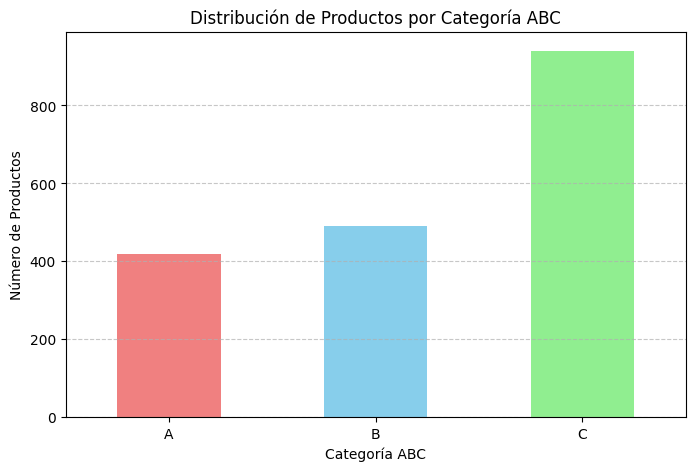

In [40]:
# 4. Visualizar la distribución de las categorías ABC
abc_counts = product_sales['ABC_Category'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
abc_counts.plot(kind='bar', color=['lightcoral', 'skyblue', 'lightgreen'])
plt.title('Distribución de Productos por Categoría ABC')
plt.xlabel('Categoría ABC')
plt.ylabel('Número de Productos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretación del Análisis ABC por Ventas:

*   **Categoría A:** Estos son los productos más importantes, que representan la mayor parte de las ventas totales. Requieren una atención especial en términos de gestión de inventario, marketing y disponibilidad.
*   **Categoría B:** Productos de importancia media. Son relevantes, pero no tan críticos como los de la Categoría A.
*   **Categoría C:** Productos con baja contribución a las ventas. A menudo son muchos en número pero de bajo valor individual, lo que puede justificar una gestión de inventario menos intensiva o incluso la consideración de descontinuarlos si no son estratégicos.

### Análisis RFM (Recencia, Frecuencia, Valor Monetario) para Segmentación de Clientes

El análisis RFM es una técnica de marketing utilizada para identificar a los mejores clientes analizando cuándo compraron por última vez (Recencia), con qué frecuencia compran (Frecuencia) y cuánto gastan (Valor Monetario).

**Métricas RFM:**
*   **Recencia (R):** Número de días desde la última compra del cliente.
*   **Frecuencia (F):** Número total de transacciones realizadas por el cliente.
*   **Valor Monetario (M):** Suma total de dinero gastado por el cliente.

In [41]:
# Para Recencia, necesitamos la fecha actual o la fecha más reciente en el dataset para calcular la 'antigüedad' de la última compra.
current_date = df['Order Date'].max()

# Calcular Recencia, Frecuencia y Valor Monetario
rfm_df = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda date: (current_date - date.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

print("RFM DataFrame creado:")
display(rfm_df.head())

RFM DataFrame creado:


,Customer ID,Recency,Frequency,Monetary
0,AA-10315,184,5,5563.560
1,AA-10375,19,9,1056.390
2,AA-10480,259,4,1790.512
3,AA-10645,55,6,5086.935
4,AB-10015,415,3,886.156


### Creación de Segmentos RFM

Para segmentar a los clientes, asignaremos puntuaciones (scores) a cada una de las métricas (Recencia, Frecuencia, Monetario). Una forma común es usar cuartiles.

*   **Recencia:** Una puntuación más baja para Recencia es mejor (menos días desde la última compra).
*   **Frecuencia:** Una puntuación más alta para Frecuencia es mejor (más compras).
*   **Monetario:** Una puntuación más alta para Valor Monetario es mejor (más gasto).

In [42]:
# Asignar puntuaciones RFM usando cuartiles
# Para Recencia: cuanto menor el valor, mejor (orden descendente en los cuartiles)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 4, labels=[4, 3, 2, 1])
# Para Frecuencia y Monetario: cuanto mayor el valor, mejor (orden ascendente en los cuartiles)
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'], 4, labels=[1, 2, 3, 4])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 4, labels=[1, 2, 3, 4])

# Combinar las puntuaciones para obtener un Score RFM total
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

print("RFM DataFrame con puntuaciones y score total:")
display(rfm_df.head())

RFM DataFrame con puntuaciones y score total:


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,AA-10315,184,5,5563.560,1,1,4,114
1,AA-10375,19,9,1056.390,4,4,1,441
2,AA-10480,259,4,1790.512,1,1,2,112
3,AA-10645,55,6,5086.935,3,2,4,324
4,AB-10015,415,3,886.156,1,1,1,111


### Definición de Segmentos de Clientes

Ahora, utilizaremos las puntuaciones RFM para definir segmentos de clientes. Algunos segmentos comunes incluyen:

*   **Campeones:** Clientes que compraron recientemente, a menudo y gastaron mucho (p.ej., puntuaciones 4-4-4, 4-4-3).
*   **Clientes Leales:** Clientes con buena frecuencia y valor, pero quizás no tan recientes (p.ej., 3-4-4, 4-3-4).
*   **Potenciales Leales:** Clientes recientes, pero que aún no han gastado mucho o comprado a menudo (p.ej., 4-1-1, 3-1-1).
*   **Clientes en Riesgo:** Clientes que compraron hace mucho, no tan a menudo y gastaron poco (p.ej., 1-1-1, 1-2-2).

Para simplificar, asignaremos segmentos basados en la combinación de sus scores R, F y M.

In [43]:
# Función para asignar segmentos de clientes
def assign_rfm_segment(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4: # Muy Reciente, Muy Frecuente, Mucho Gasto
        return 'Campeones'
    elif r >= 4 and f >= 3 and m >= 3: # Reciente, Frecuente, Buen Gasto
        return 'Clientes Leales'
    elif r >= 3 and f >= 4 and m >= 4: # Menos Reciente, Muy Frecuente, Mucho Gasto
        return 'Clientes Leales'
    elif r >= 4 and f >= 2 and m >= 2: # Reciente, Frecuencia/Gasto medio
        return 'Potenciales Leales'
    elif r >= 3 and f >= 2 and m >= 2: # Menos reciente, Frecuencia/Gasto medio
        return 'Prometedores'
    elif r <= 2 and f >= 3 and m >= 3: # Poco Reciente, Frecuente, Buen Gasto
        return 'Necesita Atención'
    elif r <= 2 and f <= 2 and m <= 2: # Poco Reciente, Poca Frecuencia, Poco Gasto
        return 'Clientes en Riesgo'
    else:
        return 'Otros'

rfm_df['Segmento_RFM'] = rfm_df.apply(assign_rfm_segment, axis=1)

print("Distribución de Segmentos RFM:")
display(rfm_df['Segmento_RFM'].value_counts())

print("RFM DataFrame con segmentos:")
display(rfm_df.head())

Distribución de Segmentos RFM:


,count
Segmento_RFM,
Otros,246
Clientes en Riesgo,193
Prometedores,100
Necesita Atención,96
Clientes Leales,79
Potenciales Leales,49
Campeones,30


RFM DataFrame con segmentos:


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segmento_RFM
0,AA-10315,184,5,5563.560,1,1,4,114,Otros
1,AA-10375,19,9,1056.390,4,4,1,441,Otros
2,AA-10480,259,4,1790.512,1,1,2,112,Clientes en Riesgo
3,AA-10645,55,6,5086.935,3,2,4,324,Prometedores
4,AB-10015,415,3,886.156,1,1,1,111,Clientes en Riesgo


### Visualización de Segmentos RFM

Visualizaremos la distribución de los clientes en los diferentes segmentos RFM para entender la composición de nuestra base de clientes.

/tmp/ipykernel_41942/1016535737.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm_df, x='Segmento_RFM', palette='viridis', order=rfm_df['Segmento_RFM'].value_counts().index)


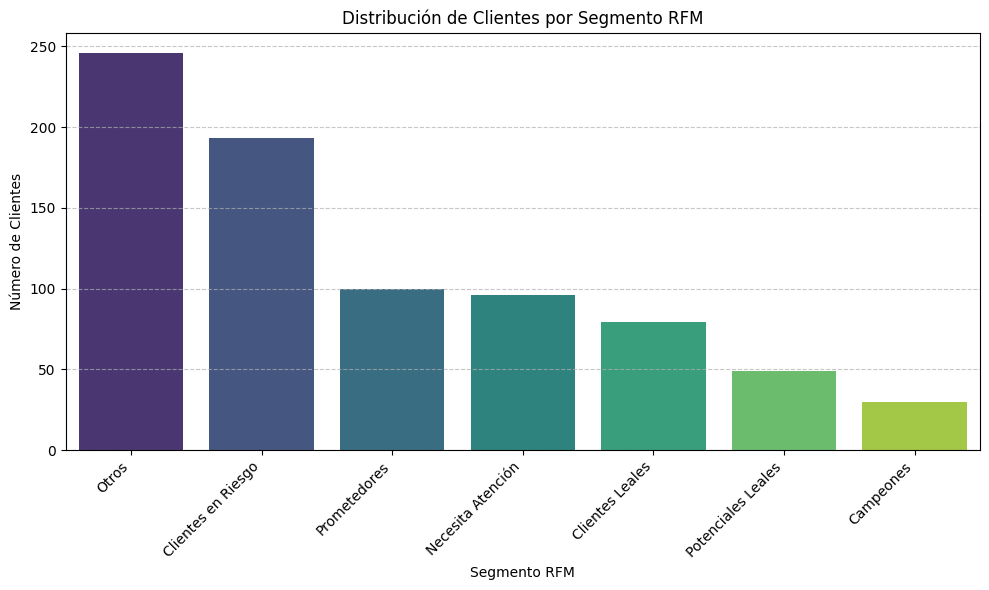

Características medias de cada Segmento RFM:


,Segmento_RFM,Recency,Frequency,Monetary
0,Campeones,14.333333,10.366667,5948.359460
1,Potenciales Leales,19.020408,7.122449,2376.955561
2,Clientes Leales,24.151899,8.886076,4559.181714
3,Prometedores,48.800000,7.750000,3539.594187
4,Otros,125.817073,5.138211,2486.434785
5,Necesita Atención,163.010417,8.572917,4954.516396
6,Clientes en Riesgo,319.502591,4.067358,1040.662948


In [44]:
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm_df, x='Segmento_RFM', palette='viridis', order=rfm_df['Segmento_RFM'].value_counts().index)
plt.title('Distribución de Clientes por Segmento RFM')
plt.xlabel('Segmento RFM')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Opcional: ver las características medias de cada segmento
segment_means = rfm_df.groupby('Segmento_RFM').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).sort_values(by='Recency').reset_index()

print("Características medias de cada Segmento RFM:")
display(segment_means)

#### Interpretación del Análisis RFM:

*   **Campeones:** Estos son tus clientes más valiosos. Han comprado recientemente, con frecuencia y gastan mucho. Debes recompensarlos y mantener su lealtad.
*   **Clientes Leales:** Compran con regularidad y gastan bien. Mantenerlos satisfechos es clave.
*   **Potenciales Leales / Prometedores:** Han comprado recientemente, pero no con tanta frecuencia o no han gastado tanto. Son excelentes candidatos para programas de fidelización y upselling.
*   **Necesita Atención:** Clientes que solían ser buenos, pero que no han comprado recientemente. Requieren campañas de reactivación.
*   **Clientes en Riesgo:** Compraron hace mucho, no muy seguido y no gastaron mucho. Es probable que necesiten un estímulo fuerte o podrían perderse.
*   **Otros:** Este segmento puede incluir clientes nuevos con poca historia o aquellos que no encajan claramente en otras categorías. Una mayor exploración podría ser útil.

### Análisis de Ventas y Ganancias por Región

Analizaremos el desempeño de las ventas y las ganancias por cada región para identificar áreas geográficas de fortaleza y debilidad.

Ventas y Ganancias por Región:


,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


/tmp/ipykernel_41942/3712951972.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_performance.index, y='Sales', data=region_performance, palette='viridis')


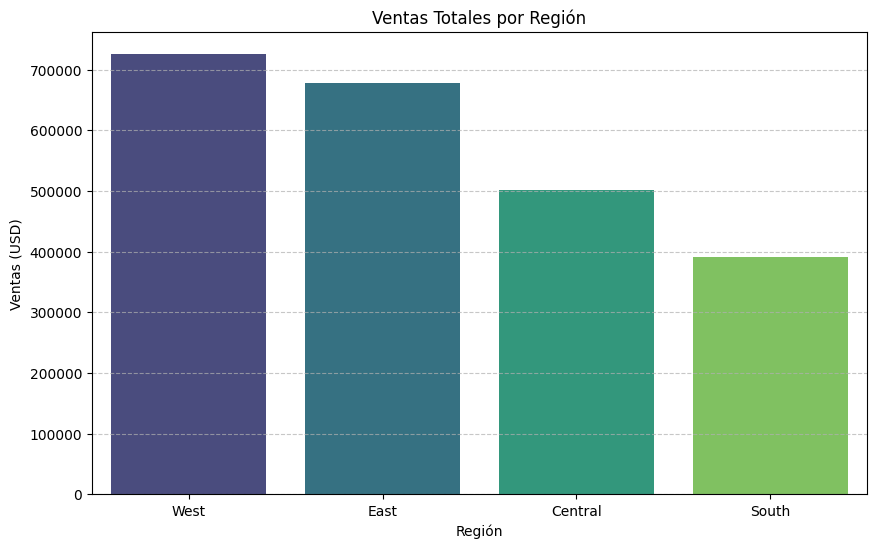

/tmp/ipykernel_41942/3712951972.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_performance.index, y='Profit', data=region_performance, palette='magma')


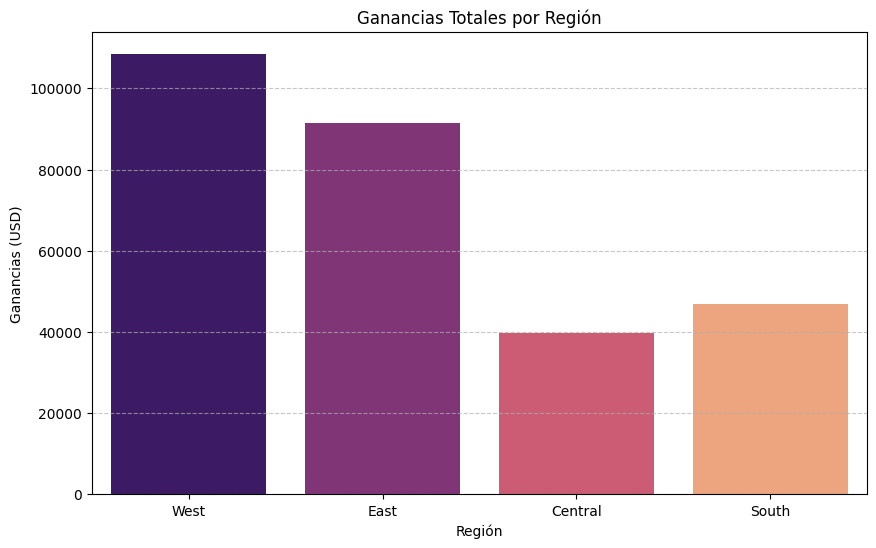

In [45]:
# 1. Calcular las ventas y ganancias totales por Región
region_performance = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

print("Ventas y Ganancias por Región:")
display(region_performance)

# 2. Visualizar las Ventas por Región
plt.figure(figsize=(10, 6))
sns.barplot(x=region_performance.index, y='Sales', data=region_performance, palette='viridis')
plt.title('Ventas Totales por Región')
plt.xlabel('Región')
plt.ylabel('Ventas (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Visualizar las Ganancias por Región
plt.figure(figsize=(10, 6))
sns.barplot(x=region_performance.index, y='Profit', data=region_performance, palette='magma')
plt.title('Ganancias Totales por Región')
plt.xlabel('Región')
plt.ylabel('Ganancias (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretación del Análisis por Región:

*   **Regiones Líderes en Ventas/Ganancias:** Identificar qué regiones contribuyen más a los ingresos y la rentabilidad general.
*   **Regiones con Oportunidades:** Detectar regiones con alto volumen de ventas pero baja rentabilidad (o incluso pérdidas), o viceversa.
*   **Estrategias Regionales:** Basado en el desempeño, se pueden diseñar estrategias específicas para cada región, como campañas de marketing localizadas, optimización de la cadena de suministro o ajustes de precios.

#Análisis de Ventas y Ganancias por Categoría

**Hallazgos Clave:**

*   **Dominio de Tecnología en Ventas y Profit:** La categoría de `Technology` (`Tecnología`) es la que genera mayores ingresos por ventas y, de manera consistente, el mayor margen de beneficio, siendo la más rentable para el negocio.

*   **Baja Rentabilidad de Muebles:** A pesar de registrar un volumen de ventas significativo, la categoría de `Furniture` (`Muebles`) presenta el margen de beneficio más bajo, indicando que muchos productos dentro de esta categoría no son rentables e incluso generan pérdidas. Esto se visualiza claramente en el gráfico de dispersión, donde una gran concentración de puntos rojos (Furniture) se encuentran por debajo de la línea de equilibrio (Profit = 0).

*   **Oportunidades en Material de Oficina:** La categoría de `Office Supplies` (`Material de Oficina`) tiene un buen margen de beneficio general, similar al de Tecnología, pero el gráfico de dispersión muestra algunos productos dentro de esta categoría que también operan con pérdidas. Esto sugiere que es un área con buen potencial, pero que requiere optimización en productos específicos.

**Recomendaciones:**

1.  **Investigar Productos No Rentables:** Es crucial profundizar en los productos específicos de `Furniture` y `Office Supplies` que están generando pérdidas. Esto podría implicar revisar precios, costos de adquisición, eficiencia de la cadena de suministro o estrategias de descuento.
2.  **Optimizar Estrategias de Precios:** Considerar ajustes en la estrategia de precios para las categorías con bajo margen o productos deficitarios, buscando un equilibrio entre volumen de ventas y rentabilidad.
3.  **Capitalizar en Tecnología:** Continuar potenciando la categoría de `Technology`, identificando sus impulsores clave de éxito y replicando esas estrategias donde sea posible.

## Conclusiones Finales y Recomendaciones para el Gerente Comercial

Basado en el análisis de nuestras ventas, la rentabilidad, el comportamiento de los productos y la segmentación de clientes, presentamos las siguientes conclusiones y recomendaciones estratégicas:


## Diagnóstico rápido

- **Technology** es la categoría más fuerte: lidera en ventas y muestra crecimiento sostenido.
- **Furniture** presenta **caída en ventas y bajo margen** → principal punto crítico.
- **Office Supplies** es estable, pero con bajo crecimiento → categoría defensiva.
- **Región Central** tiene **bajo margen relativo**, a pesar de buen volumen de ventas.
- Los **clientes “Campeones” y “Leales” concentran alto valor**, mientras que hay una base relevante de clientes en riesgo de abandono.

---

## Principales problemas detectados

1. **Caída en Furniture**  
   - Menor crecimiento + baja rentabilidad  
   - Riesgo de arrastrar resultados generales  

2. **Ineficiencia en Región Central**  
   - Alto volumen, pero bajo margen  
   - Posible problema de costos, descuentos o mix de productos  

3. **Pérdida potencial de clientes**  
   - Segmentos en riesgo con baja actividad reciente  

---

## Acciones recomendadas (priorizadas)

### 1. Alta prioridad: Rentabilidad
- Auditar **Región Central** (costos, descuentos, logística)  
- Objetivo: cerrar gap de margen vs otras regiones  

---

### 2. Alta prioridad: Corrección de categoría crítica
- Revisar estrategia en **Furniture**:
  - Ajuste de precios  
  - Reducción de descuentos agresivos  
  - Evaluar descontinuación de productos de bajo rendimiento  
- Objetivo: detener caída y mejorar margen  

---

### 3. Media prioridad: Escalar crecimiento
- Potenciar **Technology**:
  - Mayor inversión en marketing  
  - Asegurar disponibilidad de stock  
  - Promociones dirigidas  
- Objetivo: capturar crecimiento y maximizar revenue  

---

### 4. Media prioridad: Activación de clientes
- Campañas específicas para:
  - **Clientes en riesgo** → reactivación  
  - **Clientes potenciales** → aumentar frecuencia y ticket  
- Objetivo: recuperar revenue sin alto costo de adquisición  

---

### 5. Baja prioridad: Optimización de portafolio
- Revisar productos de bajo impacto:
  - Ajustar precios o eliminar  
- Objetivo: simplificar operación y mejorar eficiencia  

---

## Conclusión ejecutiva

El crecimiento del negocio está impulsado por pocas categorías y clientes clave.  
El principal riesgo está en **Furniture y la baja rentabilidad en Región Central**.  

**Enfocar en rentabilidad + escalar lo que ya funciona es la estrategia más efectiva en el corto plazo.**